# Machine Learning - Practical 2 - Introduction to Pytorch and Linear Regression with Pytorch

Names: Benjamin Uwe Büttner, Helene Kortum, Carl Lorenz
Summer Term 2026

# IMPORTANT SUBMISSION INSTRUCTIONS

You should work on the exercises in groups of 3. It is on you how you collaborate, but please make sure that everyone contributes equally and also that you understand all the solutions.
You will be asked to present your group's solution in the tutorials and you should be well prepared to present any part of it.

- When you've completed the exercise, download the notebook and rename it to ```<surname1>_<surname2>_<surname3>.ipynb```.
- Only submit the Jupyter Notebook (ipynb file). No other file is required. Upload it on `Stud.IP` -> `Machine learning 1` -> `Files` -> `Submission of Homework 1`.
- Make only one submission of the exercise per group.
- The deadline is strict.
- In addition to the submissions, every member of your group should be prepared to present the exercise in the tutorials.

## How to work on the exercise?

Generally, for machine learning you often need access to a machine with a GPU. This is not strictly required for this homework but we recommend using [Kaggle](https://www.kaggle.com/), which offers convenient access to a GPU and has all the dependencies that we need preinstalled ([here](https://gist.github.com/anwai98/444d3ff11c1365f2c610579d5df0830b) are some initial steps to work with Kaggle Notebooks). You can load this notebook on kaggle via `File` -> `Import Noteboook` -> `Browse and  Import`. Alternatively, you can also use [Colab](https://colab.research.google.com).

# Introduction

In this task, you will get to know the basic tools used by the machine learning community. Later, we will build a linear regression model with PyTorch.

**Why PyTorch for Linear Regression?**

You might wonder why we are using PyTorch to solve a simple linear problem.
Linear Regression is the most basic form of a neural network. In PyTorch, we treat a linear model as a single-neuron network. By learning the PyTorch workflow now (DataLoaders, Optimizers, and the Training Loop), you are building the foundation for the next practical. Once you understand how to "train" a simple model, moving to complex deep learning models later is simply a matter of adding more layers!

## Tutorials

Some python libraries are required to accomplish the tasks assigned in this homework. If you feel like you need to follow a tutorial before, feel free to do so:

*   [PyTorch Tutorial](https://pytorch.org/tutorials/)
*   [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html) (data visualization library on top of matplotlib)


In [401]:
# DEPENDING ON YOUR PERSONAL SET UP:

# CHANGE THE PATH TO THE DATA: 
# When using a local GPU and the file structure from our GitHub repository, use '../data/superconduct_train.csv'.
# For kaggle use '/kaggle/input/datasets/<username>/<dataset>/superconduct_train.csv' with your personal username and private uploaded dataset. 
path = '/kaggle/input/datasets/carllz/superconduct/superconduct_train.csv'

In [402]:
import random
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import pathlib
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import sampler
from sklearn.model_selection import train_test_split

In [403]:
torch.set_default_dtype(torch.float64)

## System checks

Perform some rudimentary system checks. Do we have a CUDA-capable device? Multiple? Is CuDNN active (huge speedups for some networks)?

In [404]:
torch.cuda.is_available(), torch.backends.cudnn.is_available(), torch.cuda.device_count()

(True, True, 2)

If you see now that now that there is no CUDA-capable device available, you have to activate the GPU.

On on a notebook at kaggle.com scroll on the right hand side to "Session options" and set one of the listed GPUs there.

Alternatively you could for example also use google colab or you own personal GPU


Now check the availability again (after re-running the imports)

In [405]:
torch.cuda.is_available(), torch.backends.cudnn.is_available(), torch.cuda.device_count(), torch.cuda.current_device()

(True, True, 2, 0)

Choose your device for computation. CPU or one of your CUDA devices?

In [406]:
# DO NOT CHANGE
# use_cuda = True
use_cuda = False
use_cuda = False if not use_cuda else torch.cuda.is_available()
device = torch.device('cuda:0' if use_cuda else 'cpu')
torch.cuda.get_device_name(device) if use_cuda else 'cpu'
print('Using device', device)

Using device cpu


# PyTorch: Getting to know Tensors

*feel free to skip this before 'Machine Learning with Pytorch' section if you feel confident enough*   
PyTorch is a library for machine learning on arbitrary datasets, including irregular input data such as graphs, point clouds and manifolds.

In this short tutorial we will explore some of its features to handle data in tensors.
If you want, you can look into more [detailed PyTorch tutorials](https://pytorch.org/tutorials/) online.

In [407]:
# create a numpy array
numpyarray = np.arange(10).reshape(2, 5)
# convert to pytorch tensor
a = torch.from_numpy(numpyarray)

Let us find out what the properties of this tensor 'a' are.

In [408]:
# TODO print the tensor
a

tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])

In [409]:
# TODO print its type
a.type()

'torch.LongTensor'

In [410]:
# TODO print its shape
a.shape

torch.Size([2, 5])

In [411]:
# TODO print its size
a.size()

torch.Size([2, 5])

In [412]:
# TODO create a new numpy array out of the tensor and print its size
a.numpy().size

10

Let's create some new tensors.

In [413]:
# TODO create a tensor of shape (2,5) filled with ones of type int and print it
torch.ones(2, 5, dtype=torch.int)

tensor([[1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1]], dtype=torch.int32)

In [414]:
# TODO create a tensor of shape (3,4) filled with zeros and print it
torch.zeros(3,4)

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

In [415]:
# TODO transpose the tensor 'a'
a = a.t()

Now change a value in the numpy array. Does the corresponding tensor change?

In [416]:
# TODO change value in numpy array and inspect the tensor a
arr_adjusted = numpyarray
arr_adjusted[0] = 1
b = torch.from_numpy(arr_adjusted)
b

tensor([[1, 1, 1, 1, 1],
        [5, 6, 7, 8, 9]])

Yes, the corresponding tensor does change, which can be noticed here in its third to fifth entry. 

Does it work the other way round as well?

As shown below, the change of one of the tensor's entries directly affects the others in the same way as if the array entry would have been changed before creation of the array. Therefore, the dynamic here is different as in the case above. The numpy array created from the tensor does resemble the tensor and has more than one changed entry for this reason.

In [417]:
c = torch.from_numpy(numpyarray)
c[0] = 1
print(c)
c.numpy()

tensor([[1, 1, 1, 1, 1],
        [5, 6, 7, 8, 9]])


array([[1, 1, 1, 1, 1],
       [5, 6, 7, 8, 9]])

Now we want to make use of the different devices available, namely cpu and gpu.

In [418]:
# TODO move 'a' to the gpu
a = a.to(device)

If you change a value in the tensor 'a' now, does the corresponding value in the tensor on the GPU change as well?

In the previous task we choose to move the tensor to the GPU without copying it therefore all changes made to 'a' directly apply to the tensor on the GPU as there exists currently no other version of 'a' elsewhere. 


# Machine Learning with PyTorch

Whether you are training a simple linear model or a 100-layer neural network, the PyTorch "blueprint" remains the same.

### 1. Data Loading and Preprocessing
Everything begins with data. We have to choose a dataset and split it into three distinct sets:
* **Training set:** Used by the model to learn the underlying patterns.
* **Validation set:** Used to monitor progress and tune settings during training without "polluting" the model with the test data.
* **Test set:** Held back until the very end to evaluate how the model performs on completely unseen data.

Since real-world data is often messy, we use a `Dataset` or `DataLoader` to handle preprocessing, such as **normalization**, which ensures our input features are on a similar scale.

### 2. Specify the Model, Loss, and Optimizer
Next, we define the mathematical structure of our model. In this notebook, our model represents the linear equation:
$$y = Xw + b$$

In PyTorch terminology, this is often called a **Linear Layer** or a **Fully-Connected Layer**.

We also choose a **Loss Function** (to measure how wrong we are) and an **Optimizer** (the strategy for updating our weights). A key setting here is the **Learning Rate**, which determines the size of the "steps" we take toward the best solution.

### 3. Model Fitting (The Training Loop)
The "fitting" process is a cycle repeated for a set number of **Epochs**. Each cycle consists of:
* **Forward Pass:** The data is fed through the model to produce a prediction.
* **Loss Calculation:** We compare the prediction to the actual "ground truth" value.
* **Backward Pass (Backpropagation):** We calculate the **gradient** (direction and magnitude of error) for each parameter.
* **Update:** The optimizer adjusts the weights slightly to reduce the loss.

During this process, we periodically compute the loss on the **validation set**. This helps us detect **overfitting**, which occurs when a model memorizes the training data but fails to generalize to new information. 

After training is complete, we perform one final evaluation on the **test set** to see our model's true performance.

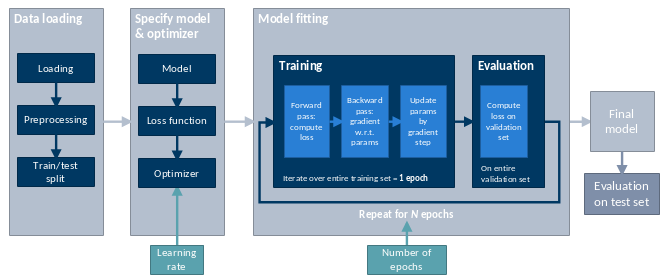

## Data Loading and Preprocessing

### Training, Validation and Test Sets

For the correct fitting of a machine learning model we need three dataset components: one for training, one for validation in the training process, and the last one for testing the results of the training on unseen data.

Note that you should not use the test set in any part of your training and model selection procedure. It should be only used for showing the final results.  

Usually, train and test datasets are already split in the provided kaggle datasets but as we work with a custom dataset, we would have to make train-test split ourselves first.

In [419]:
test_size = 0.2
target_clm='critical_temp'

In [420]:
# TODO: load data - same as in the previous practical and make train_test_split from sklearn

data = pd.read_csv(path)
train, test = train_test_split(data, test_size=test_size, random_state=0)

### Dataset

PyTorch has 2 entities to load data. They are **Dataset** and **Dataloader**.
**Dataset** is a class, which defines your data and often applies data preprocessing transformations, like normalization. It should have at least 3 functions :
* __init__ - as any other init. Usually, you would provide path to dataset here or dataset elements.
* __len__ - should return the whole dataset size
* __getitem__ - this function returns 1 pair of data and label, also here preprocessing transformations are usually applied



For the next exercise, take a look here for an example https://stanford.edu/~shervine/blog/pytorch-how-to-generate-data-parallel

In [421]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, df, target_clm, mean=None, std=None, normalise=True):
        '''
        TODO: save params to self attributes,
        x is data without target column
        y is target column
        transform df to_numpy
        '''
        self.x = df.drop(columns=[target_clm]).values.astype('float32')
        self.y = df[target_clm].values.astype('float32')
    
        self.x_tensor = torch.from_numpy(self.x)
        self.y_tensor = torch.from_numpy(self.y)
        
        self.mean = mean
        self.std = std
        self.normalise = normalise
        
        self.mean_tensor = torch.tensor(mean, dtype=torch.float32) if mean is not None else None
        self.std_tensor = torch.tensor(std, dtype=torch.float32) if std is not None else None

    def __len__(self):
        # TODO: return whole dataset length
        return len(self.x)
        
    def __getitem__(self, index):
        # TODO: return x and y for the given index, if normalise is True, normalise x using mean and std of the training set
        x = self.x_tensor[index]
        if self.normalise and self.mean is not None and self.std is not None:
            x = (x - self.mean_tensor) / self.std_tensor
        return x, self.y_tensor[index]

In [422]:
tmp_dataset = Dataset(train, target_clm, normalise=False)

In [423]:
# TODO calculate the mean and standard deviation of the train dataset
x = tmp_dataset.x 
# Seperate calculation for each feature (column):
mean = x.mean(axis=0)
std = x.std(axis=0) 

In [424]:
# TODO define new datasets with mean, std and normalise=True
conductor_train_full = Dataset(train, target_clm, mean, std, normalise=True)
conductor_test = Dataset(test, target_clm, mean, std, normalise=True)

We need to **split** the train dataset in two sets, one for training and one for validation.
While the training set needs to be quite large, the validation set can be relatively small.
Take 10 % of the dataset as validation set.
Assign samples *randomly* to the training and validation set, using a fixed seed to ensure that train and test splits are same across different model runs.

In fact, the good practice is to fix a global random seed not only the generator seed for even better reproducibility with `torch.manual_seed(0)`.
Machine learning models often involve random initialization of weights, augmentations, dropout layers, and other stochastic processes. Without fixing the random seed, each run of the model may produce slightly different results, making it challenging to reproduce specific results or debug issues.

In [425]:
# TODO split the train dataset in conductor_train and conductor_val
torch.manual_seed(0)

conductor_train, conductor_val = train_test_split(
    conductor_train_full,
    test_size=0.1,
    random_state=1  # Random seed for sklearn
)

In [426]:
batch_size = 256

To load the data for model training, we need to define the **dataloaders**.
A dataloader represents a Python iterable over a dataset and draws mini batches with random samples.
**Dataloader** calls \_\_getitem__ function from the Dataset and forms the batches.


Use the batch size as specified above.
Make sure we get shuffled samples in batches.

In [427]:
# TODO create dataloader for training, validation and test
train_dataloader =  DataLoader(
    conductor_train,
    batch_size=batch_size,
    shuffle=True
)
val_dataloader = DataLoader(
    conductor_val,
    batch_size=batch_size,
    shuffle=False
)
test_dataloader = DataLoader(
    conductor_test,
    batch_size=batch_size,
    shuffle=False
)

Let's get a data point now to see what we're dealing with.

For this, you might want to check out how python's iterator protocol works. It's simple and will give you an important insight into python: https://wiki.python.org/moin/Iterator.

In [428]:
# TODO get an element of the train_dataloader

batch_data = next(iter(train_dataloader)) # get the first batch
X, y = batch_data

In [429]:
# TODO print the dimensions of for elements from the previous step

print(f"X: {X.size()} (batch_size × features)")
print(f"y: {y.shape} (batch_size)")

print("\nindividual sample dimensions:")
print(f"features: {X[0].shape}")
print(f"label: {y[0].item()} (value)")

X: torch.Size([256, 81]) (batch_size × features)
y: torch.Size([256]) (batch_size)

individual sample dimensions:
features: torch.Size([81])
label: 5.800000190734863 (value)


x has size (\[batchsize\], 81) --> 256 elements/batches (or whatever you have defined in your data loader), 81 feature values.

y has size (\[batchsize\], 1) --> 256 elements/batches (again depends on your data loader config). There's one target value for each set of the features.

## Specify Model & Optimizer

### Specify a Model

The task is now to define a model to train on the data. In this simple example, we only need Linear Layer (often called a "fully-connected" layer in neural network contexts) as defined in *torch.nn.Linear* that produces a predicted label for a specific training input row.

Before, we set some variables:
- the input and output size of the linear layer
- how long we want to train the model (number of epochs) and
- the learning rate.


In [430]:
epochs = 15
input_dim = 81
output_dim = 1
lr = 0.001

In [431]:
class LinearRegression(torch.nn.Module):
    """
    Linear regression model inherits the torch.nn.Module
    which is the base class for all PyTorch modules.
    """
    def __init__(self, input_dim, output_dim):
        """ Initializes internal Module state. """
        super(LinearRegression, self).__init__()
        # TODO: define a linear layer for the model using torch.nn.Linear
        self.linear = torch.nn.Linear(input_dim, output_dim)  # linear layer: y = xW^T + b

    def forward(self, x):
        """ Defines the computation performed at every call. """
        # TODO: flatten the input to a suitable size for the linear layer 
        # Hint: use x.reshape(...) and the input_dim variable
        x = x.reshape(-1, 81)
        # TODO: run the flattened data through the linear layer and return the outputs
        outputs = self.linear(x)
        return outputs

### Instantiate the Model

Let us instantiate the model and take a look at the inside. It is always a good idea to verify that the actual architecture is what you intended it to be. Especially, when you start to create layers dynamically it is great for inspection/verification/debugging.

In [432]:
# TODO instantiate the model
model_manual = LinearRegression(input_dim=81, output_dim=1).float()
model_sgd = LinearRegression(input_dim=81, output_dim=1).float()

Feed the model to the GPU if available.

In [433]:
# TODO move model to device you specified above
model_manual = model_manual.to(device)
model_sgd = model_sgd.to(device)

Put the model in training mode.

In [434]:
# TODO put the model in train mode
model_manual.train()
model_sgd.train()

LinearRegression(
  (linear): Linear(in_features=81, out_features=1, bias=True)
)

### Define a Loss Function

Since we're dealing with regression problem, [MSELoss](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html) is the canonical choice for the loss.

In [435]:
# TODO define the loss function
loss_function = torch.nn.MSELoss()

## Model Fitting

### Train the Model

Everything is set for the model to train!

- In the forward pass, the prediction is made using the previously defined model on the elements of the dataloader.
- Then the loss (or error) needs to be computed by comparing the prediction to the actual label.
- In the backward pass, the model learns and updates its weights based on the current gradient.

### First, let's do all of the steps manually, without using the optimizer

**Hints:**
* define number of epochs to see the dynamic. You need to see the effect over several epochs but it should no be too long. 
* use learning rate defined above as `lr`
* when doing parameters update - do it under `with torch.no_grad():`. This would disable the gradient computation for the operations under it. And we don't need gradients for updating the weights step.
* you need to update the model parameters. See [here](https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html) for more details on how to access them
* don't forget to track the learning (loss)
* even though you should not use a preimplemented optimizer here you are allowed to call `loss.backward()` to compute the individual gradients

In [436]:
## TODO do a simple for-loop to illustrate how the gradient update if done over batches. 
## Print loss values across epochs to compare with the PyTorch optimizers lat

for epoch in range(1, epochs+1):
    total_loss = 0

    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)  # [256] -> [256, 1]

        # Forward Pass
        y_pred = model_manual(x_batch)  # y_pred = x_batch @ W^T + b
        loss = loss_function(y_pred, y_batch)
        total_loss += loss.item()

        # Backward Pass
        loss.backward()

        # Gradient descent
        with torch.no_grad():
            for param in model_manual.parameters():
                param -= lr * param.grad

        # Clearing gradient
        model_manual.zero_grad()
    print(f"Epoch {epoch}: Loss: {total_loss:.0f}")

Epoch 1: Loss: 103258
Epoch 2: Loss: 81184
Epoch 3: Loss: 68732
Epoch 4: Loss: 59375
Epoch 5: Loss: 52135
Epoch 6: Loss: 46408
Epoch 7: Loss: 41891
Epoch 8: Loss: 38359
Epoch 9: Loss: 35479
Epoch 10: Loss: 33236
Epoch 11: Loss: 31413
Epoch 12: Loss: 29960
Epoch 13: Loss: 28783
Epoch 14: Loss: 27830
Epoch 15: Loss: 27055


This was equivalent to SGD optimizer

### Now let's do it in the pytorch style using the optimizer  

The optimizer is the learning algorithm we use. In this case, we use Stochastic Gradient Descent (SGD).
Redefine the model and initialize SGD optimizer

In [437]:
# TODO Redefine the model and initialize SGD optimizer, write a train loop as above and compare the loss values

optimizer = torch.optim.SGD(model_sgd.parameters(), lr=lr) 

for epoch in range(1, epochs+1):
    total_loss = 0
    
    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)
        
        y_pred = model_sgd(x_batch)
        loss = loss_function(y_pred, y_batch)
        total_loss += loss.item()
        
        loss.backward()
        
        optimizer.step()  # update the model parameters according to gradient
        
        optimizer.zero_grad()


    print(f"Epoch {epoch}: SGD Loss: {total_loss:.4f}")

Epoch 1: SGD Loss: 103283.0184
Epoch 2: SGD Loss: 80791.1036
Epoch 3: SGD Loss: 68448.8684
Epoch 4: SGD Loss: 59114.5907
Epoch 5: SGD Loss: 51898.6528
Epoch 6: SGD Loss: 46258.0148
Epoch 7: SGD Loss: 41762.8533
Epoch 8: SGD Loss: 38218.1412
Epoch 9: SGD Loss: 35388.3000
Epoch 10: SGD Loss: 33137.5740
Epoch 11: SGD Loss: 31332.0580
Epoch 12: SGD Loss: 29889.3548
Epoch 13: SGD Loss: 28717.8535
Epoch 14: SGD Loss: 27743.1563
Epoch 15: SGD Loss: 26991.2751


### Make a Prediction

Now that our model is trained, we can make a new prediction by inputting an unseen data row from the test dataset.

Run this cell several times, does the model predict accurately?

Set the number of epochs to 15 during training and try again!

No, the model's predictions fit  very poorly. Even on 15 epochs the predicted y value often lies relatively far away from the true value. 

In [438]:
# TODO get a random element of the test dataloader

x_test, y_test = next(iter(train_dataloader))

i = random.randint(0, len(x_test) - 1)
x_sample = x_test[i].to(device).float()
y_true = y_test[i].item()

# TODO make a prediction

model_sgd.eval()
with torch.no_grad():
    y_pred = model_sgd(x_sample).item()

# print predicted label and given label
print(f"True: {y_true:.1f} | Predicted: {y_pred:.1f}")

True: 90.0 | Predicted: 48.1


### Track and Plot the Training and Validation error

What we have seen so far is the basic principle of training a model and making a prediction. But one might be interesting to see more about the training process, for instance how the training error evolves with time.

For this step, we are going to **refine the training process** and **add some important information saving for plotting**.

Create a plot using **seaborn** that contains both the losses on training set and the losses on the validation set for each epoch.

The plot should look similar to this:


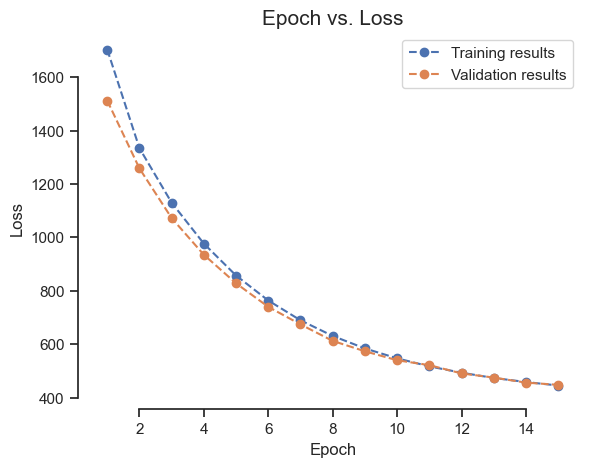


**Note:** Do not forget to add title, axis labels and a legend!
This applies in general, please keep in mind for future exercise sheets.

In [439]:
# TODO refine the training function from above
# it should contain:
# - saving of losses
# - returning the mean loss

def train_one_epoch(model_sgd, dataloader, loss_function, optimizer, device):
    model_sgd.train()
    total_loss = 0

    for x_batch, y_batch in dataloader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        y_pred = model_sgd(x_batch)
        loss = loss_function(y_pred.squeeze(1), y_batch)
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    mean_loss = total_loss / len(dataloader)
    return mean_loss

In [440]:
# TODO write a validation function that calculates the loss on the validation set
# you can also combine it with the training function

def evaluate(model_sgd, dataloader, loss_function, device):
    model_sgd.eval()
    total_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            y_pred = model_sgd(x_batch)
            loss = loss_function(y_pred.squeeze(1), y_batch)
            total_loss += loss.item()

    mean_loss = total_loss / len(dataloader)
    return mean_loss

In [441]:
# TODO write a run_training function that
# - calls the train and validate functions for each epoch
# - saves the train_losses, val_losses as arrays for each epoch

def run_training(model, train_dataloader, val_dataloader, loss_function, optimizer, device, epochs):
    
    train_losses = []
    val_losses = []

    model.to(device)

    for epoch in range(1, epochs + 1):
        
        train_loss = train_one_epoch(model, train_dataloader, loss_function, optimizer, device)
        val_loss = evaluate(model, val_dataloader, loss_function, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch}/{epochs}: Train Loss: {train_loss:.0f}, Val Loss: {val_loss:.0f}")
    
    return train_losses, val_losses


In [442]:
# TODO call the run_training function and run it for 10 epochs.
num_epochs = 15
train_losses, val_losses = run_training(
    model=model_sgd,
    train_dataloader=train_dataloader,
    val_dataloader=val_dataloader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=num_epochs
)

Epoch 1/15: Train Loss: 439, Val Loss: 389
Epoch 2/15: Train Loss: 431, Val Loss: 383
Epoch 3/15: Train Loss: 424, Val Loss: 378
Epoch 4/15: Train Loss: 417, Val Loss: 373
Epoch 5/15: Train Loss: 412, Val Loss: 370
Epoch 6/15: Train Loss: 408, Val Loss: 367
Epoch 7/15: Train Loss: 404, Val Loss: 365
Epoch 8/15: Train Loss: 401, Val Loss: 363
Epoch 9/15: Train Loss: 398, Val Loss: 360
Epoch 10/15: Train Loss: 395, Val Loss: 359
Epoch 11/15: Train Loss: 393, Val Loss: 357
Epoch 12/15: Train Loss: 391, Val Loss: 356
Epoch 13/15: Train Loss: 389, Val Loss: 355
Epoch 14/15: Train Loss: 387, Val Loss: 354
Epoch 15/15: Train Loss: 386, Val Loss: 352


In [443]:
# TODO write a plot function

def plot_losses(train_losses, val_losses):
    epochs = list(range(1, len(train_losses) + 1))
    
    df = pd.DataFrame({
        "Epoch": epochs + epochs,
        "Loss": train_losses + val_losses,
        "Set": ["Train"] * len(train_losses) + ["Validation"] * len(val_losses)
    })

    plt.figure(figsize=(8, 5))
    sns.lineplot(data=df, x="Epoch", y="Loss", hue="Set", marker="o")
    plt.title("Training and Validation Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

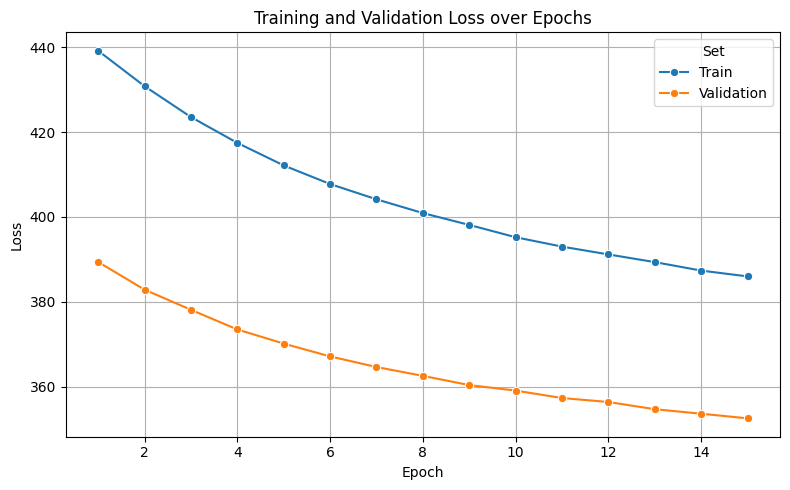

In [444]:
# TODO plot losses
plot_losses(train_losses, val_losses)

Comment on the loss curve. Does it look as expected? Why/Why not?
If not, what might be the reason.

The loss curve is surprising because it shows that the model fits the validation set better as the training set, which is unusual considering the fact that the model has been trained on the latter. The general shape of the curve is common for a loss function as it decreases for every epoch, meaning more rounds of training lead to more precise predictions, and as the decrease itself gradually decreases, meaning each new round of training has a less significant effect than its predecessor. Both the twisted 

# Hyperparameters influence

Now, once we successfully reproduced linear regression using PyTorch, lets explore the hyperparameters influence, such as learning rate or batch size.

Train several models with 30 train epochs and using different learning rates - [0.0001, 0.001, 0.01, 0.1, 1, 10].
What do you notice? Why?

*Hints*: 
* Do not forget to reinitialize models and update the optimizers
* Use different colors and line styles to display different learning rates and train-validation splits

In [445]:
num_epochs = 30
## TODO - train models with different learning rates

In [446]:
## TODO plot the losses from different models. What do you see and why?

## How do we know the amount of epochs and best learning rates?

The honest answer - we just try it out. The heuristics, which are typically used are the following
* use adaptive optimizers. Adam would be a typical example. It is an adaptive learning rate optimization algorithm that is designed to be appropriate for non-stationary objectives and problems with very noisy and/or sparse gradients. More details [here](https://paperswithcode.com/method/adam). This makes the training more robust to the choise of the the learning rate
* Use schedulers for the training. They change the value of the learning rate based on the loss behaviour. The most typical ones are
  * Early stopper . The early stopper is helpful to avoid redundunt computations and overfitting. It basically stops the train loop if the loss function does not decrease on the validation split for some time.
  * Warm up. Warm up slowly increases the learning rate in the begining of the training. This helps to avoid bad influence of not-so-good initialisation and especially helpful for the layers, which need to accumulate statistics, such as BatchNorm. We will use such layers later in the course.

### Task
Modify the the training function with the early stopper logic.
This should stop the training loop if the validation loss function does not have a relevant improvement over $N$ epochs. The improvement is only something, which is better than the $tol$ value, which stays for the tolerance.

Use $tol=2$, $N=5$, $num\_epochs=150$, $lr=0.01$ for the function start.

**Question**:
* Can $tol=0$? Why?
* How many epochs it would really run? Try to change the $lr=0.001$ and $lr=0.0001$ and see when this would stop.
* What happens if you increase the tolerance?
* What if you increase $N$?

In [447]:
## TODO: adopt the train function with the early stopper logic

In [448]:
## TODO: Train models with early stopping with the different learning rates

In [449]:
## TODO: Visualize the results. What do you see and why?

## Now lets try to explore the impact of the batch size

**Task:** Fix $num\_epochs = 150$ and $lr = 0.001$ and try to change the batch size using values $[4, 32, 128, 1024]$ for the batch size.
* What impact the batch size have? Why?

In [450]:
num_epochs = 150
lr = 0.001
## TODO: Train with different batch sizes

In [451]:
## TODO: Visualize the differences 